[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SushrutGaikwad/svm-gmu/blob/main/experiments/em_fitted_gmu.ipynb)

## Installing LaTeX on Google Colab

This is required if you want to save your plots in the `.pgf` format which LaTeX understands.

In [1]:
%%capture

!apt-get install -y texlive-xetex texlive-fonts-recommended cm-super

# Learning the Uncertainty from Data via EM

This experiment draws samples from each per-sample true GMM, re-learns a GMM per sample using Expectation Maximization with the number of components chosen by BIC, labels each by its class, then fits SVM-GMU on the learned mixtures. As the number of samples per point grows, the learned boundary converges to the SVM-GMU boundary fit on the true GMMs. This mirrors the realistic pipeline where uncertainty is estimated from sensor data rather than given.

In [2]:
%%capture

!pip install git+https://github.com/SushrutGaikwad/svm-gmu.git

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

from svm_gmu import SvmGmu
from svm_gmu.plotting import plot_uncertainty

## 1. Dataset

The same 6-point banana/crescent dataset as the other experiments.

In [4]:
X = np.array([
    [-1.8,  0.0],   # +1
    [-2.0,  1.5],   # +1
    [-1.0,  2.5],   # +1
    [ 1.5, -1.0],   # -1
    [ 1.0,  1.0],   # -1
    [ 2.0,  2.0],   # -1
])
y = np.array([+1, +1, +1, -1, -1, -1])

In [5]:
sample_1 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-4.2, -0.3],
        [-3.8,  0.3],
        [-3.0,  0.5],
        [-2.2,  0.3],
        [-1.8, -0.3],
    ]),
    "covariances": np.array([
        [[ 0.08, -0.05], [-0.05,  0.15]],
        [[ 0.10, -0.03], [-0.03,  0.12]],
        [[ 0.18,  0.00], [ 0.00,  0.06]],
        [[ 0.10,  0.03], [ 0.03,  0.12]],
        [[ 0.08,  0.05], [ 0.05,  0.15]],
    ]),
}

sample_2 = {
    "weights": np.array([0.08, 0.15, 0.22, 0.30, 0.15, 0.10]),
    "means": np.array([
        [-2.2,  0.6],
        [-1.8,  1.1],
        [-1.4,  1.5],
        [-0.8,  1.7],
        [-0.4,  1.5],
        [-0.1,  1.1],
    ]),
    "covariances": np.array([
        [[ 0.07,  0.04], [ 0.04,  0.13]],
        [[ 0.09,  0.03], [ 0.03,  0.10]],
        [[ 0.14,  0.02], [ 0.02,  0.07]],
        [[ 0.18,  0.00], [ 0.00,  0.05]],
        [[ 0.12, -0.02], [-0.02,  0.07]],
        [[ 0.08, -0.04], [-0.04,  0.12]],
    ]),
}

sample_3 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-0.6,  2.2],
        [-0.2,  2.7],
        [ 0.3,  3.0],
        [ 0.8,  3.4],
        [ 1.1,  3.8],
    ]),
    "covariances": np.array([
        [[ 0.14, -0.06], [-0.06,  0.08]],
        [[ 0.12, -0.07], [-0.07,  0.10]],
        [[ 0.10, -0.05], [-0.05,  0.14]],
        [[ 0.08,  0.03], [ 0.03,  0.16]],
        [[ 0.10,  0.06], [ 0.06,  0.15]],
    ]),
}

sample_4 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [-0.9, -0.3],
        [-0.5, -0.7],
        [-0.1, -1.0],
        [ 0.4, -1.2],
        [ 0.8, -1.1],
        [ 1.1, -0.8],
    ]),
    "covariances": np.array([
        [[ 0.07,  0.04], [ 0.04,  0.12]],
        [[ 0.09,  0.03], [ 0.03,  0.10]],
        [[ 0.15,  0.00], [ 0.00,  0.07]],
        [[ 0.15,  0.00], [ 0.00,  0.07]],
        [[ 0.09, -0.03], [-0.03,  0.10]],
        [[ 0.12, -0.05], [-0.05,  0.09]],
    ]),
}

sample_5 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [1.3,  0.7],
        [1.7,  0.3],
        [2.3,  0.1],
        [2.9,  0.3],
        [3.3,  0.7],
    ]),
    "covariances": np.array([
        [[ 0.09,  0.05], [ 0.05,  0.14]],
        [[ 0.12,  0.03], [ 0.03,  0.10]],
        [[ 0.16,  0.00], [ 0.00,  0.07]],
        [[ 0.12, -0.03], [-0.03,  0.10]],
        [[ 0.09, -0.05], [-0.05,  0.14]],
    ]),
}

sample_6 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [2.4,  2.3],
        [2.8,  2.0],
        [3.3,  2.0],
        [3.8,  2.1],
        [4.2,  2.5],
        [4.4,  3.0],
    ]),
    "covariances": np.array([
        [[ 0.08,  0.05], [ 0.05,  0.11]],
        [[ 0.12,  0.03], [ 0.03,  0.08]],
        [[ 0.15,  0.00], [ 0.00,  0.06]],
        [[ 0.13, -0.02], [-0.02,  0.07]],
        [[ 0.09, -0.04], [-0.04,  0.10]],
        [[ 0.07, -0.05], [-0.05,  0.12]],
    ]),
}

sample_uncertainty = [sample_1, sample_2, sample_3,
                      sample_4, sample_5, sample_6]

## 2. Reference SVM-GMU boundary (true GMMs)

In [6]:
LAM, SVM_ITER, SVM_SEED = 0.01, 1000, 42
model_ref = SvmGmu(lam=LAM, max_iter=SVM_ITER, batch_size=6, random_state=SVM_SEED)
model_ref.fit(X, y, sample_uncertainty=sample_uncertainty)
w_ref, b_ref = model_ref.coef_.copy(), float(model_ref.intercept_)
print('reference w =', w_ref, ' b =', round(b_ref, 4))

reference w = [-1.25267325  1.25886418]  b = -0.947


## 3. Sampler, BIC-EM fit, and boundary metrics

In [7]:
MASTER_SEED = 2026
M_CANDIDATES = list(range(1, 9))
N_INIT = 5

_grid_x = np.linspace(-5, 5, 60)
_grid_y = np.linspace(-4, 5, 60)
_GX, _GY = np.meshgrid(_grid_x, _grid_y)
_GRID_PTS = np.column_stack([_GX.ravel(), _GY.ravel()])


def sample_from_gmm(gmm: dict, n_samples: int, rng: np.random.Generator) -> np.ndarray:
    """Draw n_samples IID points from a single GMM (verbatim from convergence nb)."""
    weights = gmm["weights"]
    means = gmm["means"]
    covs = gmm["covariances"]
    n_components, d = means.shape
    comp_idx = rng.choice(n_components, size=n_samples, p=weights)
    out = np.empty((n_samples, d), dtype=np.float64)
    for m in range(n_components):
        mask = comp_idx == m
        k = int(mask.sum())
        if k == 0:
            continue
        out[mask] = rng.multivariate_normal(means[m], covs[m], size=k)
    return out


def fit_gmm_bic(
    points: np.ndarray,
    m_candidates: list[int],
    n_init: int,
    seed: int,
) -> dict:
    """Fit a GMM to points, choosing the component count by BIC.

    Parameters
    ----------
    points : ndarray of shape (n_samples, d)
        Samples to fit.
    m_candidates : iterable of int
        Candidate component counts to try; BIC selects the best.
    n_init : int
        Number of EM restarts per candidate (passed to GaussianMixture).
    seed : int
        Random seed for GaussianMixture.

    Returns
    -------
    dict
        A sample_uncertainty dict with keys 'weights' (M,),
        'means' (M, d), 'covariances' (M, d, d).
    """
    best_bic = np.inf
    best_gmm = None
    for m in m_candidates:
        gmm = GaussianMixture(
            n_components=m,
            covariance_type="full",
            n_init=n_init,
            random_state=seed,
        ).fit(points)
        bic = gmm.bic(points)
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
    return {
        "weights": best_gmm.weights_.copy(),
        "means": best_gmm.means_.copy(),
        "covariances": best_gmm.covariances_.copy(),
    }


def boundary_metrics(w_a, b_a, w_b, b_b):
    """Return (angle_deg, offset_diff, grid_rms) between two linear boundaries."""
    wa_hat = w_a / np.linalg.norm(w_a)
    wb_hat = w_b / np.linalg.norm(w_b)
    cos_t = np.clip(np.dot(wa_hat, wb_hat), -1.0, 1.0)
    angle_deg = float(np.degrees(np.arccos(cos_t)))
    offset_a = b_a / np.linalg.norm(w_a)
    offset_b = b_b / np.linalg.norm(w_b)
    offset_diff = float(abs(offset_a - offset_b))
    f_a = _GRID_PTS @ wa_hat + offset_a
    f_b = _GRID_PTS @ wb_hat + offset_b
    grid_rms = float(np.sqrt(np.mean((f_a - f_b) ** 2)))
    return angle_deg, offset_diff, grid_rms


def _draw_line(ax, w, b, xlim, **kwargs):
    """Draw the line w^T x + b = 0 within the given x-limits."""
    xs = np.linspace(xlim[0], xlim[1], 400)
    if abs(w[1]) > 1e-8:
        ys = -(w[0] * xs + b) / w[1]
        return ax.plot(xs, ys, **kwargs)[0]
    return ax.axvline(-b / w[0], **kwargs)

## 4. Sweep over sample size N

In [8]:
N_VALUES = [50, 100, 250, 500, 1000, 2000, 5000, 20000]

master_rng = np.random.default_rng(MASTER_SEED)
records = []
for n in N_VALUES:
    draw_seed = int(master_rng.integers(0, 2**31 - 1))
    rng = np.random.default_rng(draw_seed)

    su_hat = []
    for gmm in sample_uncertainty:
        pts = sample_from_gmm(gmm, n, rng)
        su_hat.append(fit_gmm_bic(pts, M_CANDIDATES, N_INIT, seed=draw_seed))

    model = SvmGmu(lam=LAM, max_iter=SVM_ITER, batch_size=6, random_state=SVM_SEED)
    model.fit(X, y, sample_uncertainty=su_hat)
    w_n, b_n = model.coef_.copy(), float(model.intercept_)
    angle, offset, rms = boundary_metrics(w_n, b_n, w_ref, b_ref)
    m_chosen = [len(s["weights"]) for s in su_hat]

    records.append({
        "n": n, "n_total": 6 * n, "su_hat": su_hat,
        "w": w_n, "b": b_n,
        "angle": angle, "offset": offset, "rms": rms, "m_chosen": m_chosen,
    })
    print(f"N={n:>6d}  n_total={6 * n:>7d}  M={m_chosen}  "
          f"angle={angle:7.3f}  offset={offset:.4f}  rms={rms:.4f}")

N=    50  n_total=    300  M=[1, 2, 1, 1, 1, 1]  angle=  0.145  offset=0.0049  rms=0.0082
N=   100  n_total=    600  M=[2, 2, 1, 1, 1, 1]  angle=  2.287  offset=0.1440  rms=0.1708
N=   250  n_total=   1500  M=[3, 2, 1, 2, 2, 2]  angle=  0.792  offset=0.0299  rms=0.0519
N=   500  n_total=   3000  M=[3, 3, 1, 2, 2, 3]  angle=  0.383  offset=0.0115  rms=0.0208
N=  1000  n_total=   6000  M=[3, 3, 2, 2, 3, 3]  angle=  0.748  offset=0.0067  rms=0.0382
N=  2000  n_total=  12000  M=[3, 3, 3, 2, 3, 3]  angle=  0.858  offset=0.0132  rms=0.0457
N=  5000  n_total=  30000  M=[5, 4, 5, 3, 3, 3]  angle=  0.495  offset=0.0031  rms=0.0242
N= 20000  n_total= 120000  M=[5, 4, 6, 4, 4, 4]  angle=  0.260  offset=0.0007  rms=0.0127


## 5. Convergence metrics

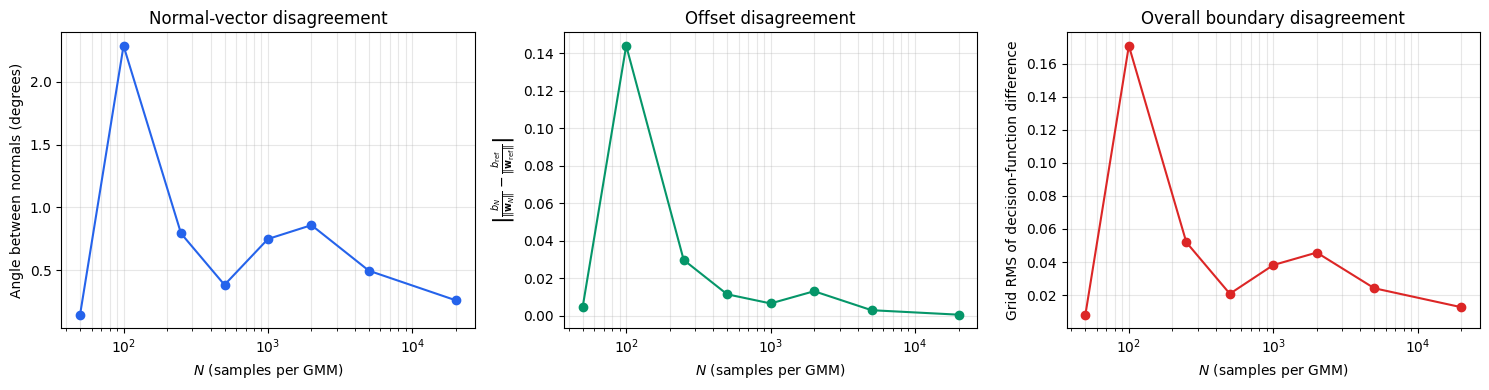

In [9]:
Ns = np.array([r["n"] for r in records], dtype=float)
angles = np.array([r["angle"] for r in records])
offsets = np.array([r["offset"] for r in records])
rms = np.array([r["rms"] for r in records])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(Ns, angles, marker="o", color="#2563eb")
axes[0].set_ylabel("Angle between normals (degrees)")
axes[0].set_title("Normal-vector disagreement")
axes[1].plot(Ns, offsets, marker="o", color="#059669")
axes[1].set_ylabel(r"$\left|\frac{b_N}{\|\mathbf{w}_N\|} - \frac{b_{\mathrm{ref}}}{\|\mathbf{w}_{\mathrm{ref}}\|}\right|$")
axes[1].set_title("Offset disagreement")
axes[2].plot(Ns, rms, marker="o", color="#dc2626")
axes[2].set_ylabel("Grid RMS of decision-function difference")
axes[2].set_title("Overall boundary disagreement")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel(r"$N$ (samples per GMM)")
    ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Boundaries at each N

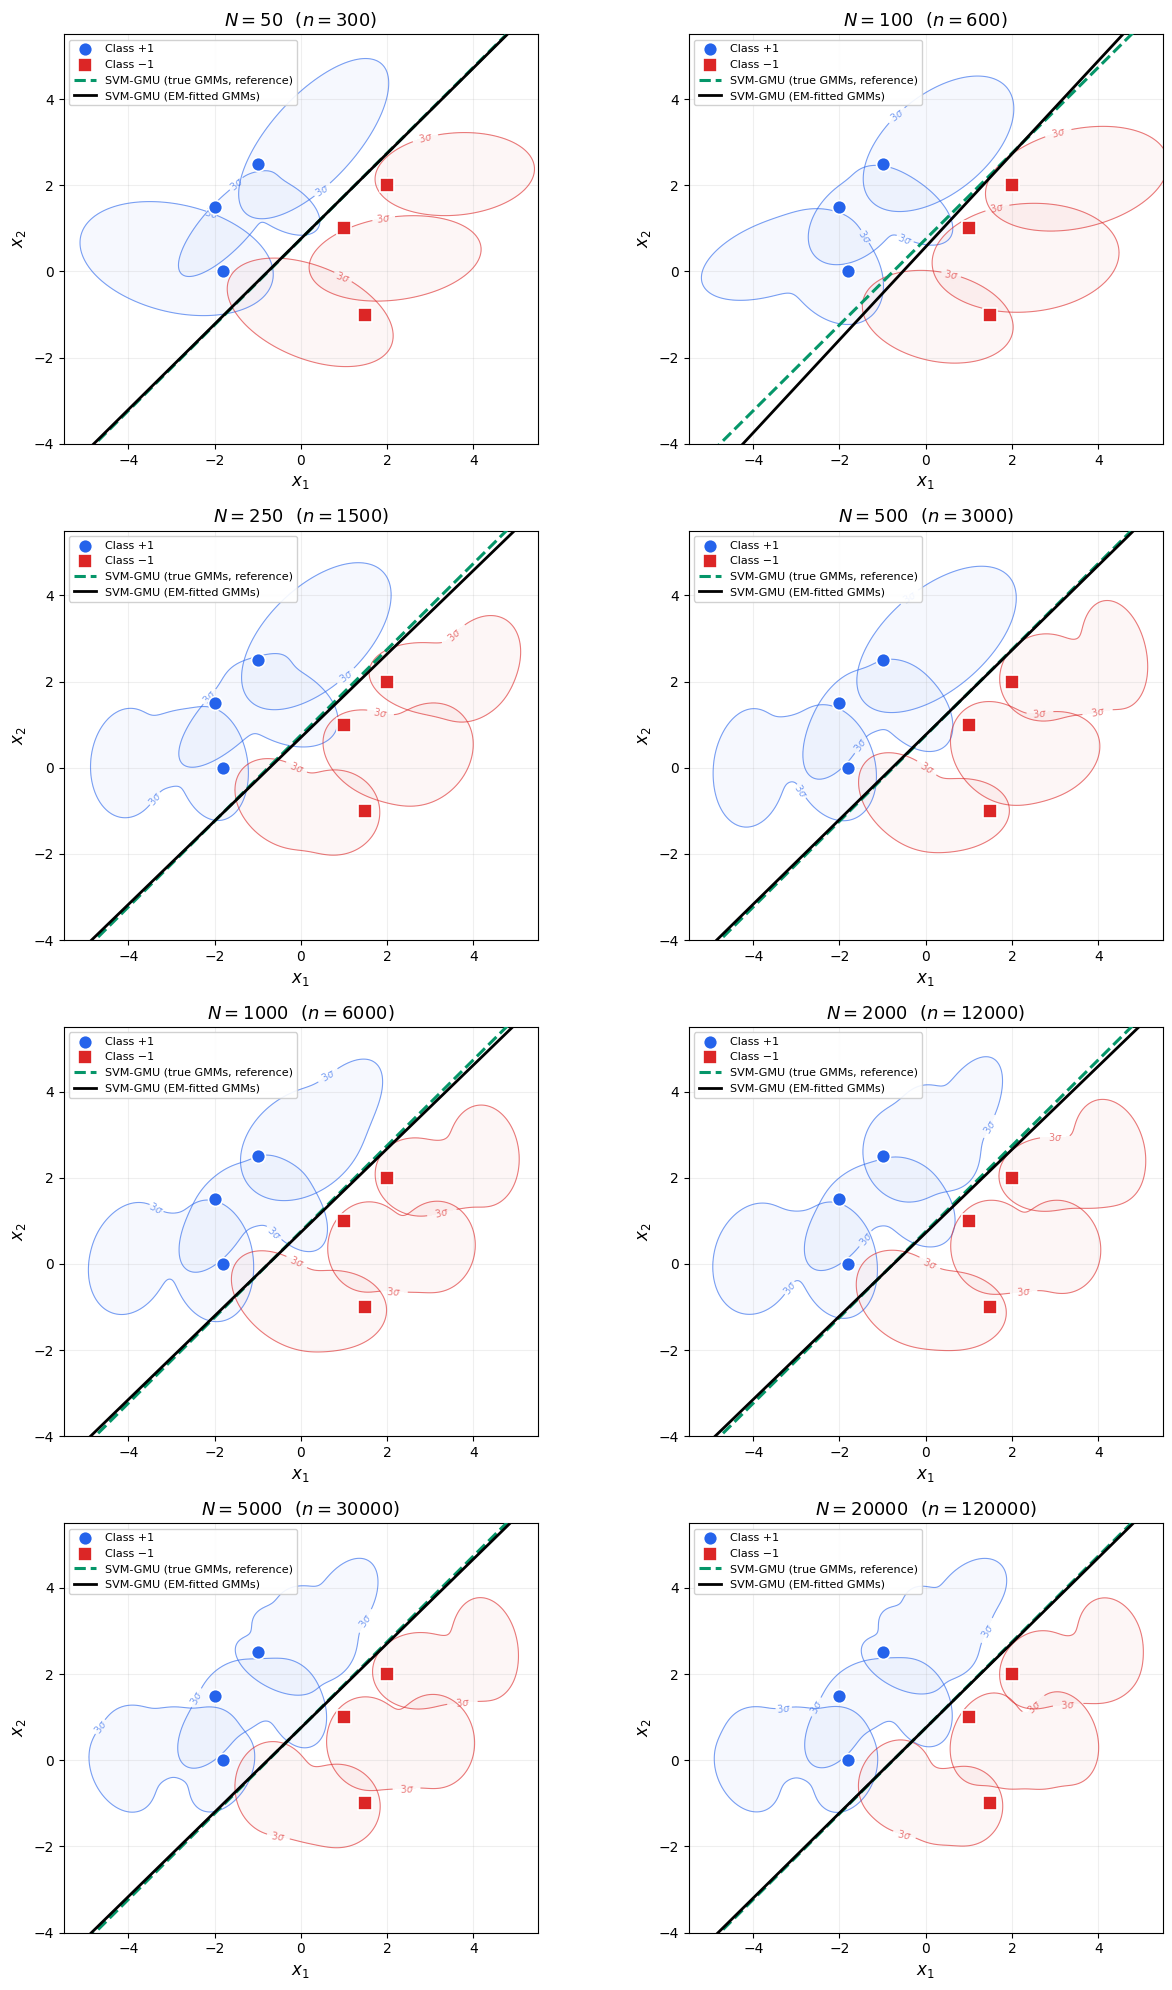

In [10]:
n_rows, n_cols = 4, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 5.0 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

xlim, ylim = (-5.5, 5.5), (-4.0, 5.5)
ref_color, learned_color = "#059669", "black"

for k, r in enumerate(records):
    ax = axes[k // n_cols, k % n_cols]
    plot_uncertainty(
        X, y, r["su_hat"], sigmas=(3,),
        title=rf"$N = {r['n']}$  $\left(n = {r['n_total']}\right)$",
        ax=ax,
    )
    _draw_line(ax, w_ref, b_ref, xlim, color=ref_color, linewidth=2.2,
               linestyle="--", zorder=4, label="SVM-GMU (true GMMs, reference)")
    _draw_line(ax, r["w"], r["b"], xlim, color=learned_color, linewidth=2.0,
               linestyle="-", zorder=5, label="SVM-GMU (EM-fitted GMMs)")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    handles, labels = ax.get_legend_handles_labels()
    keep = {"Class +1", "Class −1",
            "SVM-GMU (true GMMs, reference)", "SVM-GMU (EM-fitted GMMs)"}
    seen, uniq = set(), []
    for h, l in zip(handles, labels):
        if l in keep and l not in seen:
            seen.add(l)
            uniq.append((h, l))
    ax.legend([h for h, _ in uniq], [l for _, l in uniq],
              loc="upper left", fontsize=8, framealpha=0.9)

for k in range(len(records), n_rows * n_cols):
    axes[k // n_cols, k % n_cols].axis("off")
fig.tight_layout()
plt.show()

## 7. Interpretation

As N grows, the BIC-selected component counts climb from mostly one toward the true five or six, the EM-fitted contours sharpen into the true banana and crescent shapes, and the learned boundary (black) pulls onto the reference (green). The offset and angle metrics fall steadily toward zero. SVM-GMU therefore degrades gracefully when the mixtures are estimated rather than given: collect repeated noisy measurements, fit a GMM per example, and feed those to SVM-GMU.